# Foodpanda Pakistan — Delivery Performance Analysis
**Research Question 1:** How do delivery outcomes vary across cities, categories & order frequency?  
**Dataset:** 6,000 orders · Aug 2023 – Aug 2025


## 1. Imports & Configuration

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Simple colors for delivery status
STATUS_COLORS = {
    'Delivered': 'green',
    'Delayed': 'orange',
    'Cancelled': 'red'
}

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load & Inspect Data

In [59]:
df = pd.read_csv('Foodpanda Analysis Dataset (2).csv')

# Parse dates
for col in ['signup_date', 'order_date', 'last_order_date', 'rating_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Shape: {df.shape}")
df.head()


Shape: (6000, 20)


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,5,1478.27,Cash,38,2025-07-19,238,Active,3,2024-10-14,Cancelled
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,3,956.04,Wallet,24,2024-11-25,81,Active,2,2025-08-21,Delayed
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,2,882.51,Cash,42,2025-05-10,82,Inactive,3,2024-09-19,Delayed
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,4,231.30,Card,27,2025-07-24,45,Inactive,2,2025-06-29,Delayed
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,1,1156.69,Cash,35,2024-12-21,418,Inactive,3,2025-03-06,Cancelled


In [60]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Null Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])


=== Data Types ===
customer_id                object
gender                     object
age                        object
city                       object
signup_date        datetime64[ns]
order_id                   object
order_date         datetime64[ns]
restaurant_name            object
dish_name                  object
category                   object
quantity                    int64
price                     float64
payment_method             object
order_frequency             int64
last_order_date    datetime64[ns]
loyalty_points              int64
churned                    object
rating                      int64
rating_date        datetime64[ns]
delivery_status            object
dtype: object

=== Null Values ===
Series([], dtype: int64)


In [61]:
print("=== Delivery Status Distribution ===")
print(df['delivery_status'].value_counts())
print()
print("=== Cities ===", df['city'].unique())
print("=== Categories ===", df['category'].unique())
print("=== Payment Methods ===", df['payment_method'].unique())


=== Delivery Status Distribution ===
delivery_status
Delivered    2060
Delayed      1972
Cancelled    1968
Name: count, dtype: int64

=== Cities === ['Peshawar' 'Multan' 'Lahore' 'Karachi' 'Islamabad']
=== Categories === ['Italian' 'Dessert' 'Fast Food' 'Continental' 'Chinese']
=== Payment Methods === ['Cash' 'Wallet' 'Card']


## 3. Exploratory Data Analysis — KPI Overview

In [62]:
total       = len(df)
n_delivered = (df['delivery_status'] == 'Delivered').sum()
n_delayed   = (df['delivery_status'] == 'Delayed').sum()
n_cancelled = (df['delivery_status'] == 'Cancelled').sum()

print("=" * 40)
print(f"  Total Orders   : {total:,}")
print(f"  Delivered      : {n_delivered:,}  ({n_delivered/total*100:.1f}%)")
print(f"  Delayed        : {n_delayed:,}  ({n_delayed/total*100:.1f}%)")
print(f"  Cancelled      : {n_cancelled:,}  ({n_cancelled/total*100:.1f}%)")
print("=" * 40)


  Total Orders   : 6,000
  Delivered      : 2,060  (34.3%)
  Delayed        : 1,972  (32.9%)
  Cancelled      : 1,968  (32.8%)


## 4. Delivery Status by City

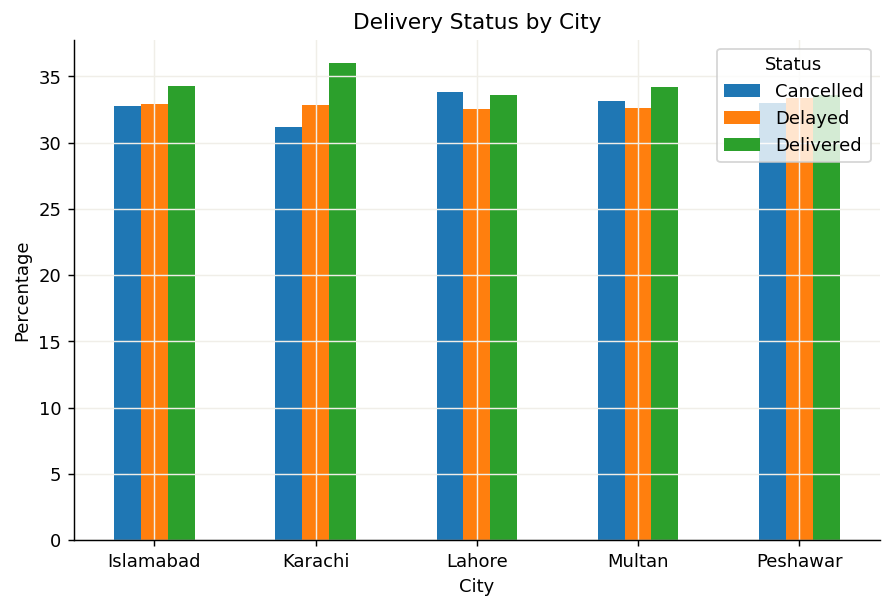

Karachi shows best delivery rate.
Lahore has highest cancellation rate.


In [63]:
# Group data by city and delivery status
city_status = df.groupby(['city', 'delivery_status']).size().reset_index(name='count')

# Calculate total orders in each city
total_orders = city_status.groupby('city')['count'].transform('sum')

# Calculate percentage
city_status['percentage'] = (city_status['count'] / total_orders) * 100

# Convert into table format
pivot = city_status.pivot(
    index='city',
    columns='delivery_status',
    values='percentage'
)

# Replace missing values with 0
pivot = pivot.fillna(0)

# Plot chart
pivot.plot(
    kind='bar',
    figsize=(8, 5)
)

# Labels and title
plt.title('Delivery Status by City')
plt.xlabel('City')
plt.ylabel('Percentage')

# Rotate city names
plt.xticks(rotation=0)

# Show legend
plt.legend(title='Status')

# Show chart
plt.show()

print("Karachi shows best delivery rate.")
print("Lahore has highest cancellation rate.")

## 5. Delivery Status by Food Category

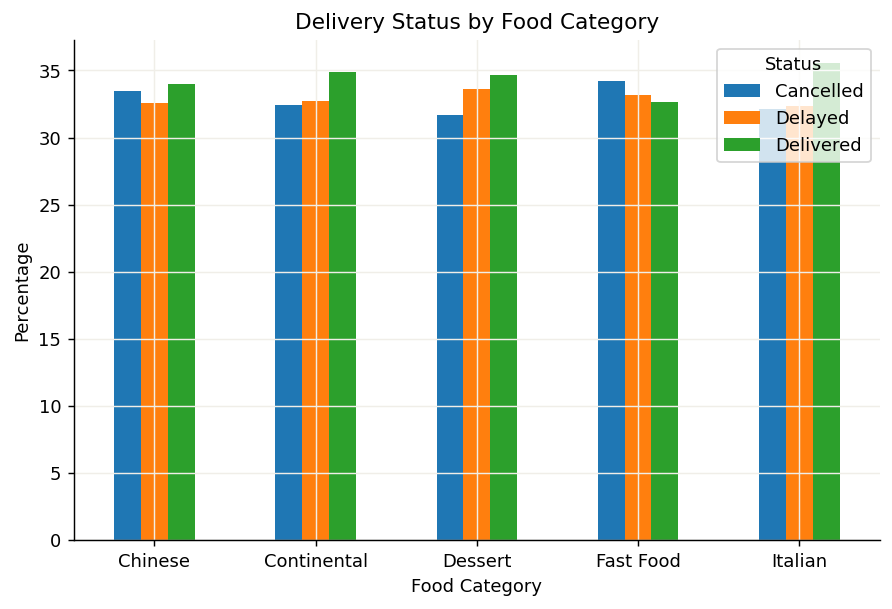

Italian has best delivery rate.
Fast Food has highest cancellation rate.


In [64]:
# Group data by food category and delivery status
cat_status = df.groupby(['category', 'delivery_status']).size().reset_index(name='count')

# Calculate total orders in each category
total_orders = cat_status.groupby('category')['count'].transform('sum')

# Calculate percentage
cat_status['percentage'] = (cat_status['count'] / total_orders) * 100

# Convert data into table format
pivot = cat_status.pivot(
    index='category',
    columns='delivery_status',
    values='percentage'
)

# Replace missing values with 0
pivot = pivot.fillna(0)

# Create bar chart
pivot.plot(
    kind='bar',
    figsize=(8, 5)
)

# Add labels and title
plt.title('Delivery Status by Food Category')
plt.xlabel('Food Category')
plt.ylabel('Percentage')

# Rotate labels
plt.xticks(rotation=0)

# Show legend
plt.legend(title='Status')

# Show chart
plt.show()

print("Italian has best delivery rate.")
print("Fast Food has highest cancellation rate.")

## 6. Order Frequency vs Delivery Performance

In [65]:
df['freq_group'] = pd.cut(
    df['order_frequency'],
    bins=[0, 17, 34, 50],
    labels=['Low (1–17)', 'Medium (18–34)', 'High (35–50)']
)

freq_pct = (
    df.groupby(['freq_group', 'delivery_status'])
    .size()
    .reset_index(name='count')
)
totals_f = freq_pct.groupby('freq_group')['count'].transform('sum')
freq_pct['pct'] = freq_pct['count'] / totals_f * 100
pivot_f = freq_pct.pivot(index='freq_group', columns='delivery_status', values='pct').fillna(0)
pivot_f = pivot_f[['Delivered', 'Delayed', 'Cancelled']]
print(pivot_f.round(1))


delivery_status  Delivered  Delayed  Cancelled
freq_group                                    
Low (1–17)            32.9     34.3       32.8
Medium (18–34)        34.6     33.0       32.4
High (35–50)          35.7     31.1       33.2


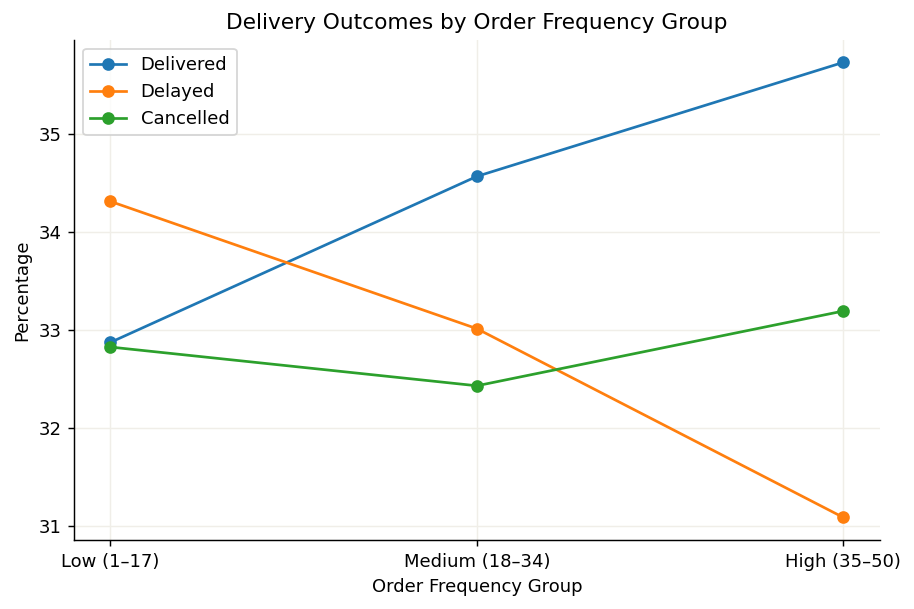

Delay rate decreases for high-frequency customers.
Delivered rate increases for frequent customers.


In [66]:
# Create figure
plt.figure(figsize=(8, 5))

# Plot lines
plt.plot(pivot_f.index, pivot_f['Delivered'], marker='o', label='Delivered')
plt.plot(pivot_f.index, pivot_f['Delayed'], marker='o', label='Delayed')
plt.plot(pivot_f.index, pivot_f['Cancelled'], marker='o', label='Cancelled')

# Add title and labels
plt.title('Delivery Outcomes by Order Frequency Group')
plt.xlabel('Order Frequency Group')
plt.ylabel('Percentage')

# Show legend
plt.legend()

# Show chart
plt.show()

print("Delay rate decreases for high-frequency customers.")
print("Delivered rate increases for frequent customers.")

## 8. Quarterly Temporal Trend

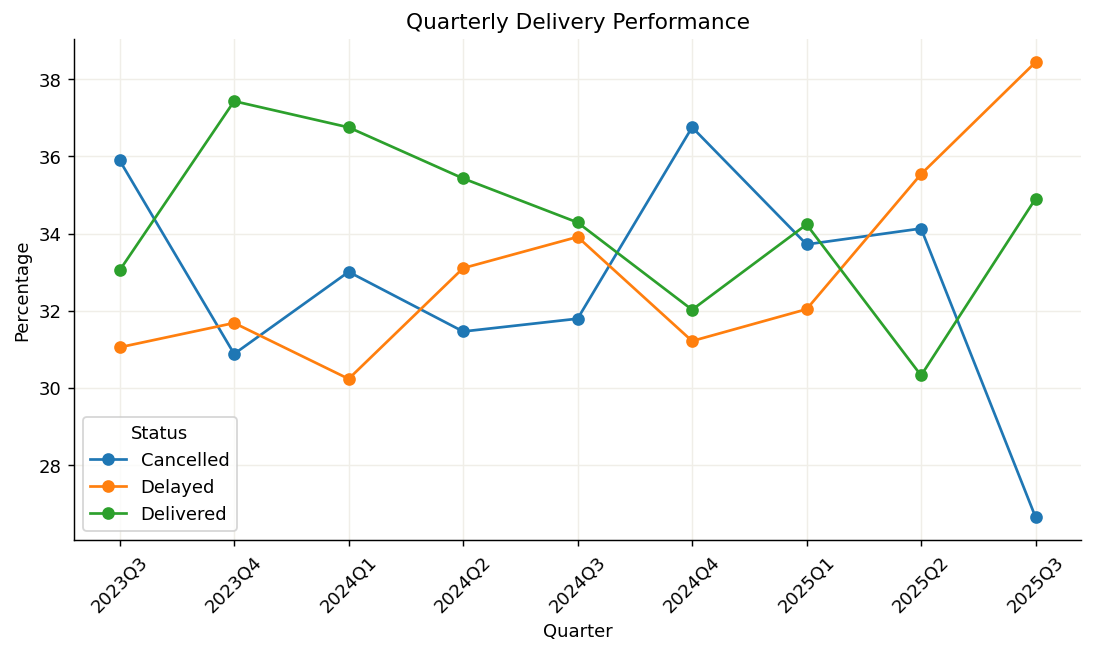

In [67]:
# Create quarter column from order date
df['quarter'] = df['order_date'].dt.to_period('Q')

# Group data by quarter and delivery status
qtr = df.groupby(['quarter', 'delivery_status']).size().reset_index(name='count')

# Calculate total orders per quarter
total_orders = qtr.groupby('quarter')['count'].transform('sum')

# Calculate percentage
qtr['percentage'] = (qtr['count'] / total_orders) * 100

# Convert into table format
pivot = qtr.pivot(
    index='quarter',
    columns='delivery_status',
    values='percentage'
)

# Replace missing values with 0
pivot = pivot.fillna(0)

# Convert quarter format to string
pivot.index = pivot.index.astype(str)

# Plot line chart
pivot.plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)

# Add title and labels
plt.title('Quarterly Delivery Performance')
plt.xlabel('Quarter')
plt.ylabel('Percentage')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show legend
plt.legend(title='Status')

# Show chart
plt.show()

## 14. Key Findings & Actionable Recommendations

### 📊 Key Findings

| Finding | Evidence |
|---------|----------|
| Near-uniform distribution | ~33% each for Delivered/Delayed/Cancelled — likely synthetic data |
| Best-performing city | **Karachi** (36% delivery rate) |
| Highest cancellation city | **Lahore** (33.9%) |
| Best food category | **Italian** (35.5% delivery rate) |
| Worst category | **Fast Food** (34.2% cancellation) |
| Frequency effect | Delay rate drops 3.2pp Low→High frequency |
| Hotspot | **Multan × Continental** (37.4% cancel), **Islamabad × Fast Food** (36.1%) |
| Q4 2024 | Cancellation spike to 36.8% |
| Q3 2025 | Delay surge to 38.4% |

### 🚫 Reduce Cancellations
- Focus on **Lahore Fast Food** and **Multan Continental** — highest-risk combinations
- Proactive ETA notifications for these segments
- Investigate payment-method interactions with real transaction data

### ⏱ Reduce Delays  
- Low-frequency customers face the highest delay rate (34.3%)
- Implement **pre-positioning riders** for new/infrequent customer zones
- Audit operational logs for Q4 2024 and Q3 2025 spikes

### 📈 Leverage Order Frequency
- High-frequency users show 35.7% delivery rate vs 32.9% for low
- **Loyalty incentives** that increase order frequency can organically improve outcomes
- Convert Medium → High frequency users with personalized offers

---
> ⚠️ **Dataset Limitation:** The near-uniform 33%/33%/34% split strongly suggests synthetic data.  
> Treat directional patterns as hypotheses to validate against real production data.
